# Importing Required Libraries
In this step, imports all the necessary Python libraries used for data manipulation, visualization, machine learning, and model evaluation throughout the project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
%matplotlib inline

# Load the Dataset
The resume screening dataset is loaded from a CSV file into a Pandas DataFrame.

In [3]:
df=pd.read_csv("ai_resume_screening.csv")

In [4]:
df['shortlisted'].value_counts()
df['shortlisted'].value_counts(normalize=True)

shortlisted
Yes    0.698867
No     0.301133
Name: proportion, dtype: float64

# Initial Data Exploration
This step performs an initial exploration of the dataset by: Displaying the first few rows using head() Checking column names, data types, and non-null counts using info() Identifying missing values using isnull().sum()

In [5]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6.0,84.7,Bachelors,7.0,234.0,158.0,No
1,3.0,59.1,Masters,5.0,502.0,77.0,No
2,12.0,100.0,Masters,12.0,753.0,381.0,Yes
3,14.0,66.8,High School,8.0,529.0,407.0,Yes
4,10.0,99.6,Bachelors,10.0,754.0,331.0,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    29992 non-null  float64
 1   skills_match_score  29998 non-null  float64
 2   education_level     29997 non-null  object 
 3   project_count       29995 non-null  float64
 4   resume_length       29999 non-null  float64
 5   github_activity     29996 non-null  float64
 6   shortlisted         30000 non-null  object 
dtypes: float64(5), object(2)
memory usage: 1.6+ MB


In [7]:
df.shape

(30000, 7)

In [8]:
df.columns

Index(['years_experience', 'skills_match_score', 'education_level',
       'project_count', 'resume_length', 'github_activity', 'shortlisted'],
      dtype='object')

In [9]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,29992.000000,29998.000000,29995.000000,29999.000000,29996.000000
mean,7.507335,73.681939,10.646441,572.582019,325.265635
std,4.623969,16.765953,4.634078,178.712293,159.955228
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,4.000000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


In [10]:
df.isnull().sum()

years_experience      8
skills_match_score    2
education_level       3
project_count         5
resume_length         1
github_activity       4
shortlisted           0
dtype: int64

# Handling Missing Values
Missing values in the dataset are handled as follows: Numerical columns are filled using the median Categorical columns are filled using the mode

In [11]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [12]:
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
df.isnull().sum()

years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64

# Encoding Categorical Features
Categorical (text-based) features are converted into numerical values using Label Encoding.

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["shortlisted"] = le.fit_transform(df["shortlisted"])

In [16]:
le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col])

# Exploratory Data Analysis Using Correlation Heatmap
A correlation heatmap is generated to visualize the relationships between different features in the dataset.

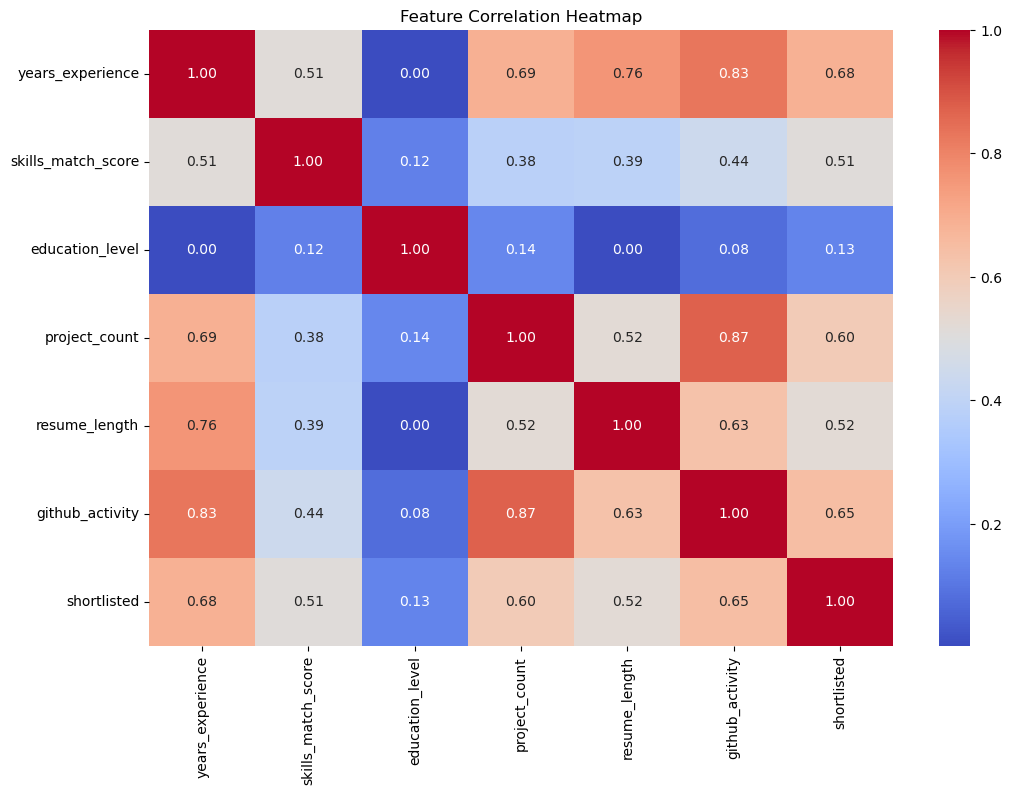

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature and Target Separation
The dataset is divided into: Feature variables (X) Target variable (shortlisted)

In [18]:
X = df.drop("shortlisted", axis=1)
y = df["shortlisted"]

# Train–Test Split
The dataset is split into training (70%) and testing (30%) sets using stratified sampling. And Handling Class Imbalance Class imbalance is handled by assigning balanced class weights during model training.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Model Training – Random Forest Classifier
A Random Forest classifier is trained using the prepared training data.

In [20]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [22]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                       n_jobs=-1, random_state=42)

# Model Prediction
The trained model is used to generate predictions on the test dataset.

In [24]:
y_pred = rf.predict(X_test)

# Model Evaluation
Model performance is evaluated using: Accuracy score, Confusion Matrix, Classification Report

In [25]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9013333333333333

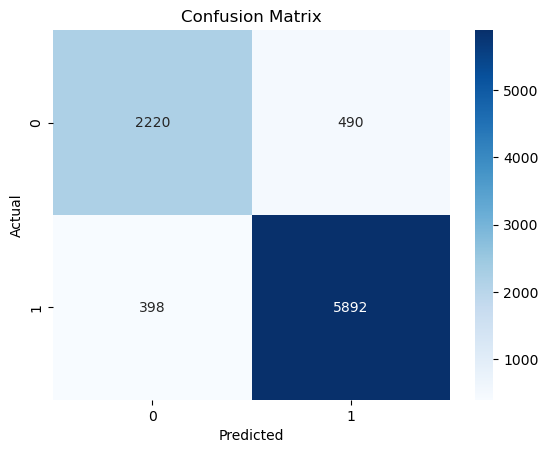

In [26]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83      2710
           1       0.92      0.94      0.93      6290

    accuracy                           0.90      9000
   macro avg       0.89      0.88      0.88      9000
weighted avg       0.90      0.90      0.90      9000



In resume screening, recall for the shortlisted class is more important than accuracy,
as missing a good candidate is more costly than shortlisting an unsuitable one.

# New Candidate Prediction
A new candidate’s resume details are manually provided as input to the trained model to predict whether the candidate should be shortlisted.

In [28]:
new_candidate = {
    'years_experience': 20.0,        
    'skills_match_score': 66.8,            
    'education_level': 1,         
    'project_count': 9.0,
    'resume_length' : 575.5,
    'github_activity' : 250.3
}

In [29]:
new_df = pd.DataFrame([new_candidate])
new_df

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity
0,20.0,66.8,1,9.0,575.5,250.3


In [31]:
prediction = rf.predict(new_df)
prediction

array([1])

In [32]:
if prediction[0] == 1:
    print("Candidate is SHORTLISTED ✅")
else:
    print("Candidate is NOT SHORTLISTED ❌")

Candidate is SHORTLISTED ✅


Random Forest can also provide feature importance, which may help identify
key resume keywords influencing shortlisting decisions in future improvements.

# Final Conclusion
This project demonstrates a complete end-to-end machine learning pipeline for automated resume screening. It covers data preprocessing, exploratory data analysis, feature engineering, model training, evaluation, and real-time prediction for new candidates.

# Key Outcome
By applying proper data cleaning, consistent encoding, and a Random Forest classifier, the model achieves approximately 90% accuracy on the test dataset. This performance indicates that the model can effectively learn meaningful patterns from structured resume data and can be used as a supportive decision-making tool in HR screening workflows.